```yaml
version: 1.0
author: Rolland Palffy (palffy.rolland@codespring.ro)
reviewers:
    - Laszlo Barabasi (Laszlo Barabas (barabas.laszlo@codespring.ro)
```

# Files and Asynchronous I/O

This chapter introduces how to work with files in Python, including reading, writing, and managing file resources efficiently. It also covers asynchronous I/O, which allows us to perform slow operations like network or disk access concurrently, making our programs more responsive and efficient.

## Reading and writing files

Use `open()` to read or write a file. This function returns a file object, and is most commonly used with two positional arguments and one keyword argument: `open(filename, mode, encoding=None)`. It is good practice to use the `with` keyword when dealing with file objects. It wraps the execution of a block in a *context manager*, ensuring that the file is properly closed after its suite finishes, even if an exception is raised at some point.

Here's an example of writing multiple lines to a file. If the file doesn't exist, it will be created automatically:

In [1]:
with open("temp/workfile", "w", encoding="utf-8") as f:
    f.write("line1\nline2\nline3\n")

We can use the `open()` in read mode to read the file's content:

In [2]:
with open("temp/workfile", "r") as f:
    content = f.read()
    print(content)

line1
line2
line3



We can iterate over the lines using a `for` loop:

In [3]:
with open("temp/workfile") as f:
    for line in f:
        print(line.strip())

line1
line2
line3


We can read a binary file using `"rb"` mode like an image, which can be displayed in Jupyter Notebook using `IPython.display`:

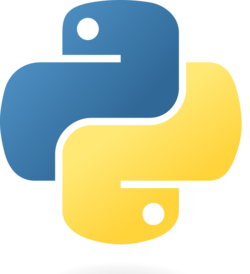

In [4]:
from IPython.display import Image, display

with open("img/python-logo.png", "rb") as f:
    image = f.read()
    display(Image(data=image))

Use `pathlib` module to handle filesystem paths: https://docs.python.org/3/library/pathlib.html

## Asynchronous I/O

Asynchronous I/O (async IO) allows programs to handle multiple input/output operations concurrently without blocking the main execution thread. Python's built-in `asyncio` library provides functions to write asynchronous code using the `async` and `await` keywords.

In [5]:
import asyncio

async def foo():
    print("hello")
    await asyncio.sleep(1)
    print("goodbye")

await foo()

hello
goodbye


### Dealing with multiple coroutines

`asyncio.gather()` allows us to run multiple *coroutines* concurrently. It schedules all the provided coroutines to run at the same time and waits until all of them are completed before proceeding. The results are returned as a list in the same order as the coroutines were passed in.

In [6]:
coro1 = asyncio.sleep(1, result=1)
coro2 = asyncio.sleep(2, result=2)
coro3 = asyncio.sleep(3, result=3)
await asyncio.gather(coro1, coro2, coro3)

[1, 2, 3]

`asyncio.TaskGroup()` (*added in version Python v3.11*) is an asynchronous context manager holding a group of tasks, providing stronger safety guarantees than `gather()`. Tasks can be added to the group using `create_task()`. All tasks are awaited when the context manager exits.

In [7]:
async with asyncio.TaskGroup() as tg:
    for i in range(1, 4):
        tg.create_task(asyncio.sleep(i))

print("finished")

finished


### Background tasks

Coroutines do not begin execution until they are scheduled. In the following example, we create 3 coroutines but we don't `await` them until later. They will run sequentially, waiting for 0.5, 1, and 1.5 seconds respectively, for a total of 3 seconds:

In [8]:
async def sleepy():
    cor1 = asyncio.sleep(0.5)
    cor2 = asyncio.sleep(1)
    cor3 = asyncio.sleep(1.5)
    # ...
    await cor1
    await cor2
    await cor3

await sleepy()

To schedule the execution of a coroutine in the background, we need to use `asyncio.create_task()`. This reduces the execution time to the duration of the longest task, 1.5 seconds:

In [9]:
async def sleepy_tasks():
    task1 = asyncio.create_task(asyncio.sleep(0.5))
    task2 = asyncio.create_task(asyncio.sleep(1))
    task3 = asyncio.create_task(asyncio.sleep(1.5))
    # ...
    await task1
    await task2
    await task3

await sleepy_tasks()

Note that creating background tasks *without holding a reference to them* [can lead to hard-to-debug bugs (Heisenbug)](https://textual.textualize.io/blog/2023/02/11/the-heisenbug-lurking-in-your-async-code/)! Where possible, use the safer `asyncio.TaskGroup.create_task()` alternative.

### Async main

Use `asyncio.run()` to start executing the top-level entry point of an async program. Since Jupyter Notebook is already running an async *event loop*, this code will raise an error:

In [10]:
async def main():
    await asyncio.sleep(1)
    print('hello')

if __name__ == '__main__':
    asyncio.run(main()) # RuntimeError: asyncio.run() cannot be called from a running event loop

RuntimeError: asyncio.run() cannot be called from a running event loop

### Async generator

Generators are special functions that yield values one at a time, allowing iteration over potentially large or infinite sequences without loading everything into memory. In Python, a function becomes a generator when it uses the `yield` keyword.

When combined with asynchronous programming, an `async def` function can use `yield` or `yield from` along with `await` to create an asynchronous generator. This allows us to produce values over time, pausing between yields to await asynchronous operations.

The `async for` statement is used to iterate over asynchronous generators. It automatically awaits each item, making it ideal for processing data that arrives asynchronously, such as reading file chunks or network responses.

Learn more about coroutines and tasks: https://docs.python.org/3/library/asyncio-task.html

In [11]:
async def fake_file_chunks():
    yield b"hello, " # using 'yield' creates a generator
    await asyncio.sleep(0.1)
    yield b"world"
    await asyncio.sleep(0.2)
    yield b"" # bytes literal

async for chunk in fake_file_chunks():
    print(chunk)

b'hello, '
b'world'
b''
